In [ ]:
# Problem 4. Accomplish the tasks performed in Problem 1, this time using OpenAI
# codex. (25%)

# Assignment 03, Problem 4

This notebook was built with OpenAI Codex.

Paul Schwartzberg

An MLP classifier for FashionMNIST, assembled from steps 01–08. Run the cells in order. Requires PyTorch, torchvision, torchmetrics and matplotlib. The first run downloads FashionMNIST; training takes a few minutes on CPU. The test set remains separate.

The cells share their objects directly rather than rerunning earlier scripts. Training saves the history and model weights; the chart uses that history, and predictions use the trained model.

## Step 01: Load and split FashionMNIST

In [1]:
import torch
import torchvision
from torchvision.transforms import v2


transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=transform
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=transform
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000]
)

print(f"Training images:   {len(train_data):,}")
print(f"Validation images: {len(valid_data):,}")
print(f"Test images:       {len(test_data):,}")

Training images:   55,000
Validation images: 5,000
Test images:       10,000


## Step 02: Create DataLoaders

In [2]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Training batches:   {len(train_loader):,}")
print(f"Validation batches: {len(valid_loader):,}")
print(f"Test batches:       {len(test_loader):,}")

Training batches:   1,719
Validation batches: 157
Test batches:       313


## Step 03: Inspect a training sample

In [3]:
image, label = train_data[0]
class_name = train_data.dataset.classes[label]

print(f"Shape: {list(image.shape)}")
print(f"Dtype: {image.dtype}")
print(f"Class: {class_name}")

Shape: [1, 28, 28]
Dtype: torch.float32
Class: Ankle boot


## Step 04: Define the model and training components

In [4]:
import torch
from torch import nn
import torchmetrics


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 300),
    nn.ReLU(),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(model)
print(f"Trainable parameters: {trainable_parameters:,}")

Device: cpu
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=10, bias=True)
)
Trainable parameters: 266,610


## Step 05: Define the training function

In [5]:
import torch


def train(model, train_loader, valid_loader, loss_fn, optimizer, metric, device, epochs):
    """Record mean training loss and training and validation accuracy each epoch.

    The loss function must return the mean loss for a batch.
    """
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    model.to(device)
    metric.to(device)

    for _ in range(epochs):
        model.train()
        metric.reset()
        total_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(images)
            loss = loss_fn(predictions, labels)
            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            metric.update(predictions.detach(), labels)

        history["train_losses"].append(total_loss / total_samples)
        history["train_metrics"].append(metric.compute().item())

        model.eval()
        metric.reset()
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                predictions = model(images)
                metric.update(predictions, labels)

        history["valid_metrics"].append(metric.compute().item())
        metric.reset()

    return history

## Step 06: Train for 20 epochs

In [6]:
import json
from pathlib import Path

repo_root = Path.cwd()

print("Training for 20 epochs...", flush=True)
history = train(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    metric=accuracy,
    device=device,
    epochs=20,
)

history_path = repo_root / "training_history.json"
history_path.write_text(json.dumps(history, indent=2) + "\n", encoding="utf-8")
model_path = repo_root / "fashion_mnist_model.pt"
torch.save(model.state_dict(), model_path)

print(f"Final training accuracy: {history['train_metrics'][-1]:.4%}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4%}")
print(f"History saved to {history_path.name}")
print(f"Model weights saved to {model_path.name}")

Training for 20 epochs...


Final training accuracy: 92.8455%
Final validation accuracy: 87.0000%
History saved to training_history.json
Model weights saved to fashion_mnist_model.pt


## Step 07: Plot training and validation accuracy

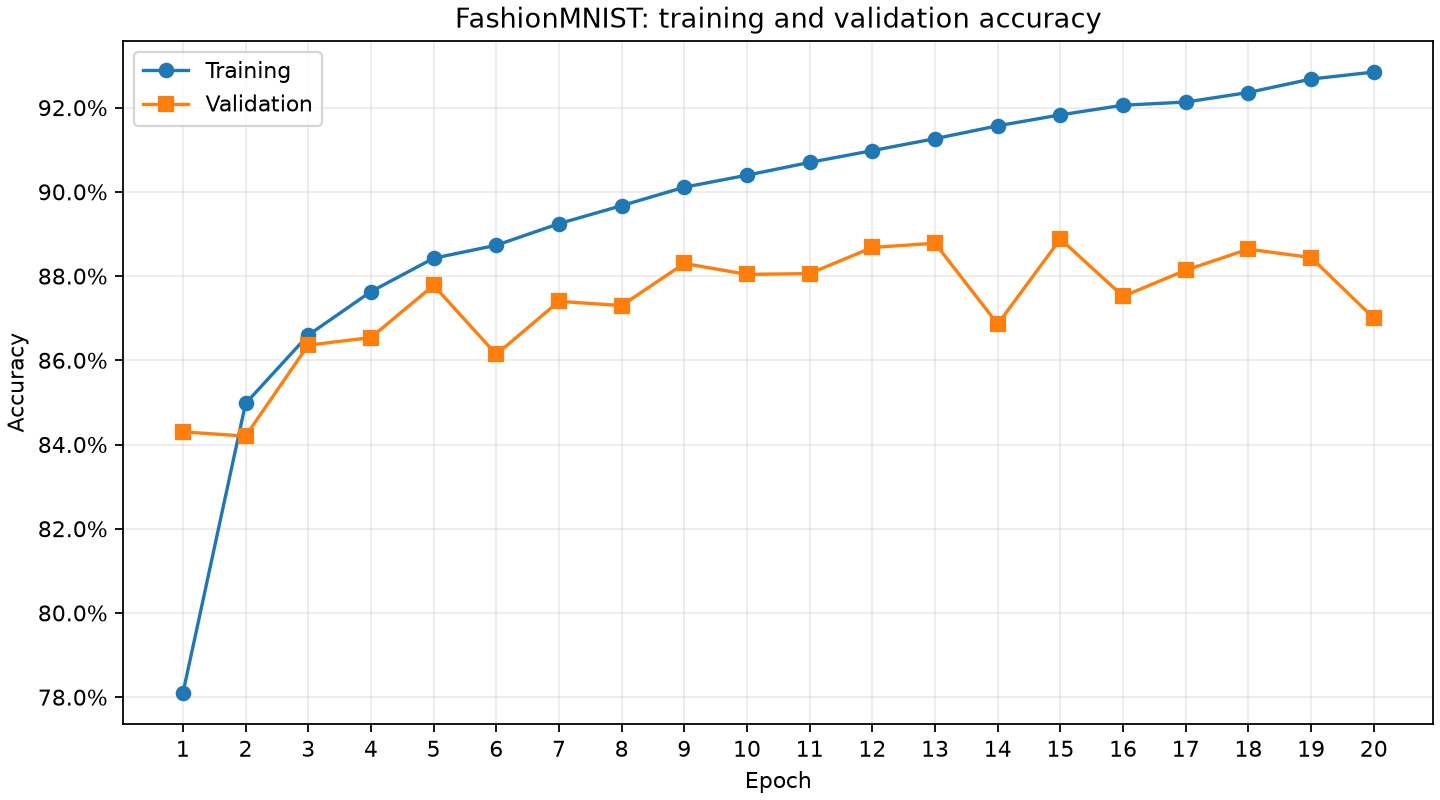

Chart saved to training_accuracy.png


In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from IPython.display import Image, display

epochs = range(1, len(history["train_metrics"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.plot(epochs, history["train_metrics"], marker="o", label="Training")
ax.plot(epochs, history["valid_metrics"], marker="s", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("FashionMNIST: training and validation accuracy")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xticks(list(epochs))
ax.grid(alpha=0.25)
ax.legend()

output_path = repo_root / "training_accuracy.png"
fig.savefig(output_path, dpi=160)
display(Image(filename=str(output_path)))
plt.close(fig)
print(f"Chart saved to {output_path.name}")

## Step 08: Inspect validation predictions

In [8]:
model.eval()
classes = valid_data.dataset.classes
samples = [valid_data[index] for index in range(3)]
images = torch.stack([image for image, _ in samples]).to(device)

with torch.no_grad():
    probabilities = torch.softmax(model(images), dim=1).cpu()

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
for index, (probs, (_, true_label)) in enumerate(zip(probabilities, samples)):
    predicted_label = probs.argmax().item()
    print(f"\nValidation image {index}: predicted {classes[predicted_label]}; true {classes[true_label]}")
    print("Softmax probabilities:")
    for class_name, probability in zip(classes, probs.tolist()):
        print(f"  {class_name}: {probability:.6f}")

    top_probs, top_labels = probs.topk(4)
    print("Top 4 classes:")
    for rank, (label, probability) in enumerate(zip(top_labels.tolist(), top_probs.tolist()), start=1):
        print(f"  {rank}. {classes[label]}: {probability:.6f}")

Total parameters: 266,610

Validation image 0: predicted Sneaker; true Sneaker
Softmax probabilities:
  T-shirt/top: 0.000016
  Trouser: 0.000152
  Pullover: 0.000005
  Dress: 0.000026
  Coat: 0.000036
  Sandal: 0.001638
  Shirt: 0.000026
  Sneaker: 0.890368
  Bag: 0.000201
  Ankle boot: 0.107532
Top 4 classes:
  1. Sneaker: 0.890368
  2. Ankle boot: 0.107532
  3. Sandal: 0.001638
  4. Bag: 0.000201

Validation image 1: predicted Coat; true Coat
Softmax probabilities:
  T-shirt/top: 0.000000
  Trouser: 0.000000
  Pullover: 0.003134
  Dress: 0.000000
  Coat: 0.996805
  Sandal: 0.000000
  Shirt: 0.000062
  Sneaker: 0.000000
  Bag: 0.000000
  Ankle boot: 0.000000
Top 4 classes:
  1. Coat: 0.996805
  2. Pullover: 0.003134
  3. Shirt: 0.000062
  4. T-shirt/top: 0.000000

Validation image 2: predicted Pullover; true Pullover
Softmax probabilities:
  T-shirt/top: 0.004288
  Trouser: 0.000291
  Pullover: 0.545206
  Dress: 0.001922
  Coat: 0.239018
  Sandal: 0.000013
  Shirt: 0.205040
  Sneaker